<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/oversampling_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Data manipulation
import pandas as pd

# Scikit-learn
# from sklearn.datasets import load_diabetes
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Consistent plot style
# sns.set_theme(style="whitegrid", palette="muted")
# plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13})
print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# import dataset
df = pd.read_csv("https://raw.githubusercontent.com/lovnishverma/datasets/refs/heads/main/Crop.csv")


df.head()

,N,P,K,ph,EC,S,Cu,Fe,Mn,Zn,B,label
0,143,69,217,5.9,0.58,0.23,10.20,116.35,59.96,54.85,21.29,pomegranate
1,170,36,216,5.9,0.15,0.28,15.69,114.20,56.87,31.28,28.62,pomegranate
2,158,66,219,6.8,0.34,0.20,15.29,65.87,51.81,57.12,27.59,pomegranate
3,133,45,207,6.4,0.94,0.21,8.48,103.10,43.81,68.50,47.29,pomegranate
4,132,48,218,6.7,0.54,0.19,5.59,63.40,56.40,46.71,31.04,pomegranate


In [ ]:
df.describe()

,N,P,K,ph,EC,S,Cu,Fe,Mn,Zn,B
count,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000
mean,135.701613,52.508065,161.401613,6.106290,0.885468,0.484085,17.315452,117.212500,219.905887,34.340839,28.750710
std,31.808083,24.673538,81.285780,0.693782,0.637214,5.775388,6.441150,62.775199,341.998793,11.543871,19.636447
min,30.000000,10.000000,51.000000,4.500000,0.010000,0.011100,0.180000,3.810000,20.580000,17.990000,1.020000
25%,116.000000,30.000000,89.000000,5.700000,0.297500,0.086000,12.592500,68.312500,58.785000,24.727500,13.442500
50%,138.000000,54.000000,157.500000,6.100000,0.780000,0.168000,16.910000,108.245000,73.580000,31.425000,23.225000
75%,160.000000,75.000000,206.000000,6.500000,1.390000,0.240000,21.102500,155.620000,163.665000,43.542500,42.767500
max,198.000000,100.000000,369.000000,8.000000,2.480000,113.200000,35.000000,276.720000,1572.540000,70.000000,74.560000


In [ ]:
df['label'].value_counts()

,count
label,
pomegranate,104
mango,104
grapes,104
mulberry,104
ragi,104
potato,100


In [ ]:
df['label'].value_counts()

,count
label,
pomegranate,104
mango,104
grapes,104
mulberry,104
ragi,104
potato,100


In [ ]:
# drop rows where label column has mulberry, ragi or potato

df.drop(df[df['label'] == 'mulberry'].index, inplace = True)
df.drop(df[df['label'] == 'ragi'].index, inplace = True)
df.drop(df[df['label'] == 'potato'].index, inplace = True)

In [ ]:
df['label'].value_counts()

,count
label,
pomegranate,104
mango,104
grapes,104


In [ ]:
# encoding on label column

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

In [ ]:
df['label'].value_counts()

,count
label,
2,104
1,104
0,104


In [ ]:
df.shape

(312, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 312 entries, 0 to 311
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   N       312 non-null    int64  
 1   P       312 non-null    int64  
 2   K       312 non-null    int64  
 3   ph      312 non-null    float64
 4   EC      312 non-null    float64
 5   S       312 non-null    float64
 6   Cu      312 non-null    float64
 7   Fe      312 non-null    float64
 8   Mn      312 non-null    float64
 9   Zn      312 non-null    float64
 10  B       312 non-null    float64
 11  label   312 non-null    int64  
dtypes: float64(8), int64(4)
memory usage: 31.7 KB


In [ ]:
df.isnull().sum()

,0
N,0
P,0
K,0
ph,0
EC,0
S,0
Cu,0
Fe,0
Mn,0
Zn,0


In [ ]:
df.describe()

,N,P,K,ph,EC,S,Cu,Fe,Mn,Zn,B,label
count,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000
mean,135.878205,58.137821,144.766026,6.078846,0.554423,0.193678,14.079647,109.253782,76.344455,40.343750,43.385769,1.000000
std,25.434828,20.877924,54.177507,0.584528,0.411446,0.081315,4.699410,37.128706,71.300468,11.441893,16.697243,0.817808
min,80.000000,11.000000,56.000000,4.500000,0.010000,0.014200,5.000000,50.110000,20.580000,17.990000,4.360000,0.000000
25%,116.000000,40.750000,89.000000,5.700000,0.187500,0.150000,10.367500,80.312500,50.640000,31.855000,30.685000,0.000000
50%,137.000000,61.000000,159.000000,6.100000,0.490000,0.190000,13.985000,105.065000,65.015000,40.860000,42.675000,1.000000
75%,154.000000,76.000000,190.000000,6.500000,0.870000,0.260000,17.835000,131.437500,87.947500,47.507500,56.462500,2.000000
max,180.000000,95.000000,342.000000,7.200000,1.500000,0.350000,30.010000,255.990000,992.780000,70.000000,74.560000,2.000000


In [ ]:
df.corr()

,N,P,K,ph,EC,S,Cu,Fe,Mn,Zn,B,label
N,1.000000,-0.368411,0.122131,0.305746,-0.428528,-0.197864,-0.020870,-0.286499,-0.074316,0.245531,-0.525147,0.213169
P,-0.368411,1.000000,0.213775,-0.287822,0.525897,0.313256,-0.067027,0.234018,-0.108986,-0.237156,0.559387,0.024105
K,0.122131,0.213775,1.000000,0.199339,0.446413,0.537637,-0.208801,-0.028405,-0.359264,0.124718,0.023043,0.825507
ph,0.305746,-0.287822,0.199339,1.000000,-0.199767,-0.053905,0.036631,-0.049576,-0.044338,0.251078,-0.333405,0.249549
EC,-0.428528,0.525897,0.446413,-0.199767,1.000000,0.539498,-0.050203,0.195148,-0.025485,-0.172820,0.564125,0.289833
S,-0.197864,0.313256,0.537637,-0.053905,0.539498,1.000000,-0.172098,0.145783,-0.092528,0.009384,0.341116,0.560092
Cu,-0.020870,-0.067027,-0.208801,0.036631,-0.050203,-0.172098,1.000000,0.105118,0.284850,-0.097787,-0.046969,-0.187067
Fe,-0.286499,0.234018,-0.028405,-0.049576,0.195148,0.145783,0.105118,1.000000,0.227515,-0.233390,0.255148,-0.179118
Mn,-0.074316,-0.108986,-0.359264,-0.044338,-0.025485,-0.092528,0.284850,0.227515,1.000000,-0.187609,-0.089050,-0.286030
Zn,0.245531,-0.237156,0.124718,0.251078,-0.172820,0.009384,-0.097787,-0.233390,-0.187609,1.000000,-0.232002,0.209834


In [ ]:
df.cov()

,N,P,K,ph,EC,S,Cu,Fe,Mn,Zn,B,label
N,646.930456,-195.635893,168.296170,4.545647,-4.484572,-0.409231,-2.494513,-270.559056,-134.773475,71.455088,-223.025308,4.434084
P,-195.635893,435.887697,241.804054,-3.512509,4.517523,0.531813,-6.576318,181.403689,-162.237593,-56.652576,195.004572,0.411576
K,168.296170,241.804054,2935.202315,6.312720,9.951038,2.368540,-53.161337,-57.137601,-1387.795321,77.312102,20.844602,36.575563
ph,4.545647,-3.512509,6.312720,0.341673,-0.048044,-0.002562,0.100623,-1.075939,-1.847893,1.679240,-3.254032,0.119293
EC,-4.484572,4.517523,9.951038,-0.048044,0.169288,0.018050,-0.097070,2.981167,-0.747621,-0.813589,3.875545,0.097524
S,-0.409231,0.531813,2.368540,-0.002562,0.018050,0.006612,-0.065765,0.440138,-0.536462,0.008731,0.463148,0.037246
Cu,-2.494513,-6.576318,-53.161337,0.100623,-0.097070,-0.065765,22.084454,18.341364,95.444751,-5.258043,-3.685555,-0.718939
Fe,-270.559056,181.403689,-57.137601,-1.075939,2.981167,0.440138,18.341364,1378.540775,602.299647,-99.149432,158.178432,-5.438778
Mn,-134.773475,-162.237593,-1387.795321,-1.847893,-0.747621,-0.536462,95.444751,602.299647,5083.756805,-153.053667,-106.015720,-16.678424
Zn,71.455088,-56.652576,77.312102,1.679240,-0.813589,0.008731,-5.258043,-99.149432,-153.053667,130.916908,-44.323514,1.963473


In [ ]:
# separate features and target

df_features = df.drop('label', axis=1)
df_target = df['label']

In [ ]:
# test train split

X_train, X_test, y_train, y_test = train_test_split(df_features,df_target, test_size=0.2, random_state=42)

In [ ]:
# Model Training
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score = accuracy_score(y_test, model.predict(X_test))
print(f"{accuracy_score * 100} %")

98.4126984126984 %


In [ ]:
# check for accuracy score
acc = model.score(X_test, y_test)

print(f"{acc * 100} %")

98.4126984126984 %


In [ ]:
# predict for unseen data
pred = model.predict([[146,	64,	219,	5.8,	0.59,	0.25,	10.24,	116.34,	59.94,	54.84,	21.24]])

# decode label
pred = le.inverse_transform(pred)

print(pred[0])

pomegranate


In [ ]:
from sklearn.metrics import classification_report
class_report = classification_report(y_test, model.predict(X_test))
print(class_report)

              precision    recall  f1-score   support

           0       1.00      0.95      0.98        21
           1       0.95      1.00      0.98        21
           2       1.00      1.00      1.00        21

    accuracy                           0.98        63
   macro avg       0.98      0.98      0.98        63
weighted avg       0.98      0.98      0.98        63



In [ ]:
from sklearn.metrics import confusion_matrix

cm  = confusion_matrix(y_test, model.predict(X_test))

cm

array([[20,  1,  0],
       [ 0, 21,  0],
       [ 0,  0, 21]])

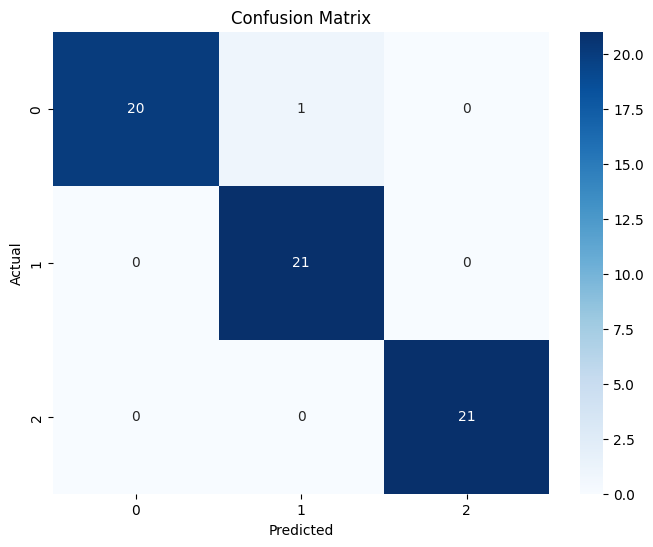

In [ ]:
from sklearn.metrics import confusion_matrix
# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, model.predict(X_test))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig("confusion_matrix_plot.png")
plt.show()

**Learn more:** https://www.geeksforgeeks.org/machine-learning/metrics-for-machine-learning-model/



---



In [ ]:
# import dataset
df = pd.read_csv("https://raw.githubusercontent.com/lovnishverma/datasets/refs/heads/main/Crop.csv")

df.head()

,N,P,K,ph,EC,S,Cu,Fe,Mn,Zn,B,label
0,143,69,217,5.9,0.58,0.23,10.20,116.35,59.96,54.85,21.29,pomegranate
1,170,36,216,5.9,0.15,0.28,15.69,114.20,56.87,31.28,28.62,pomegranate
2,158,66,219,6.8,0.34,0.20,15.29,65.87,51.81,57.12,27.59,pomegranate
3,133,45,207,6.4,0.94,0.21,8.48,103.10,43.81,68.50,47.29,pomegranate
4,132,48,218,6.7,0.54,0.19,5.59,63.40,56.40,46.71,31.04,pomegranate


In [ ]:
# drop rows where label column has mulberry, ragi or potato

df.drop(df[df['label'] == 'mulberry'].index, inplace = True)
df.drop(df[df['label'] == 'ragi'].index, inplace = True)
df.drop(df[df['label'] == 'potato'].index, inplace = True)

In [ ]:
df.head()

,N,P,K,ph,EC,S,Cu,Fe,Mn,Zn,B,label
0,143,69,217,5.9,0.58,0.23,10.20,116.35,59.96,54.85,21.29,pomegranate
1,170,36,216,5.9,0.15,0.28,15.69,114.20,56.87,31.28,28.62,pomegranate
2,158,66,219,6.8,0.34,0.20,15.29,65.87,51.81,57.12,27.59,pomegranate
3,133,45,207,6.4,0.94,0.21,8.48,103.10,43.81,68.50,47.29,pomegranate
4,132,48,218,6.7,0.54,0.19,5.59,63.40,56.40,46.71,31.04,pomegranate


In [ ]:
# drop all the rows where label is 'grapes'
df = df.drop(df[df['label'] == 'grapes'].index)

In [ ]:
# make this data intentionally imblance (delete 80 rows where label = 	'pomegranate')
# Isolate the indices of the first 80 rows where the label is 'pomegranate'
indices_to_drop = df[df['label'] == 'pomegranate'].index[:80]

# Drop these rows from the main DataFrame
df = df.drop(indices_to_drop)



# Verify the new class distribution
print(df['label'].value_counts())

label
mango          104
pomegranate     24
Name: count, dtype: int64


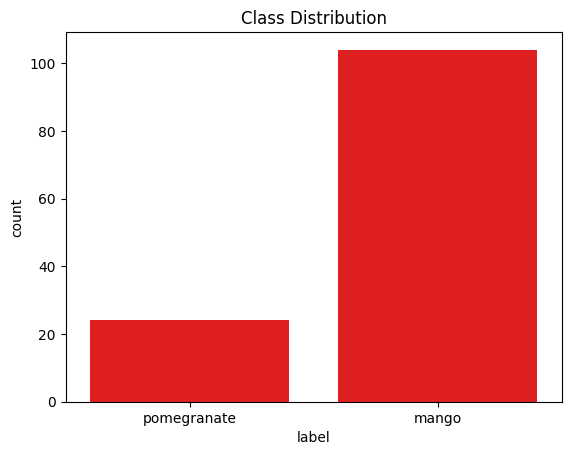

In [ ]:
# Verify the new class distribution using seaborn
import seaborn as sns
sns.countplot(x='label', data=df, color='red')
plt.title('Class Distribution')
plt.show()


In [ ]:
# separate features and target

df_features = df.drop('label', axis=1)
df_target = df['label']

In [ ]:
df.describe()

,N,P,K,ph,EC,S,Cu,Fe,Mn,Zn,B
count,128.000000,128.00000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000
mean,121.054688,73.53125,162.515625,5.864844,0.892969,0.242305,13.885703,123.817344,79.407813,36.938438,56.325312
std,22.859140,16.38654,31.549732,0.687526,0.352877,0.062840,3.993993,42.454856,85.720270,11.089830,15.202936
min,80.000000,12.00000,56.000000,4.500000,0.090000,0.040000,5.570000,50.270000,22.040000,20.660000,10.350000
25%,104.000000,72.00000,144.750000,5.375000,0.650000,0.190000,10.560000,89.580000,57.115000,27.097500,52.160000
50%,122.500000,78.00000,165.500000,5.900000,0.880000,0.245000,13.720000,118.690000,69.915000,35.190000,60.040000
75%,137.000000,84.00000,188.000000,6.400000,1.160000,0.290000,17.040000,159.400000,84.170000,45.575000,67.925000
max,177.000000,89.00000,218.000000,7.200000,1.500000,0.350000,30.010000,209.200000,992.780000,69.760000,74.560000


In [ ]:
# test train split

X_train, X_test, y_train, y_test = train_test_split(df_features,df_target, test_size=0.2, random_state=42, stratify=df_target)


*In scikit-learn's train_test_split, the stratify parameter ensures that the splitting process preserves the exact same proportion of classes in both the training and testing sets as they exist in the original dataset.*

In [ ]:
# Model Training
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# Check for Model Accuracy
from sklearn.metrics import accuracy_score
accuracy_score = accuracy_score(y_test, model.predict(X_test))
print(f"{accuracy_score * 100} %")

96.15384615384616 %


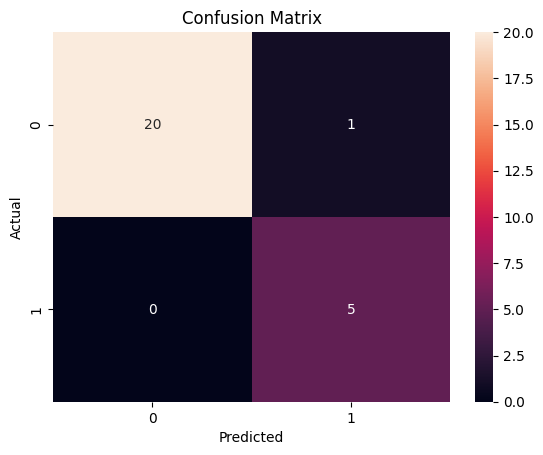

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, model.predict(X_test))

sns.heatmap(cm, annot=True)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
df.tail()

,N,P,K,ph,EC,S,Cu,Fe,Mn,Zn,B,label
203,148,74,196,5.4,0.80,0.310,17.92,147.96,78.05,23.14,67.20,mango
204,121,45,61,6.1,0.90,0.189,12.01,132.03,120.31,32.21,29.10,mango
205,124,34,102,5.6,0.23,0.132,12.30,143.30,122.40,48.21,48.21,mango
206,131,24,61,6.5,0.74,0.206,30.01,209.20,992.78,29.40,17.02,mango
207,126,31,56,6.2,0.51,0.312,22.32,165.20,302.20,25.99,25.21,mango


In [ ]:
df.head()

,N,P,K,ph,EC,S,Cu,Fe,Mn,Zn,B,label
80,135,51,195,6.9,0.90,0.16,9.21,118.35,67.13,47.73,42.37,pomegranate
81,137,53,177,6.8,0.98,0.19,19.80,102.44,58.38,45.95,27.97,pomegranate
82,161,57,186,5.8,0.93,0.27,9.50,100.99,51.96,43.01,32.55,pomegranate
83,153,78,188,5.6,0.09,0.26,18.72,117.45,53.95,67.84,42.67,pomegranate
84,141,69,211,5.7,0.71,0.16,12.33,116.81,68.31,43.30,42.22,pomegranate


# **Handling Class Imblance Dataset in Classification Problems**

---

# 🧭 1. First: Diagnose the Imbalance

```python
from collections import Counter
print(Counter(y))
```

* Mild imbalance → 60:40
* Moderate → 80:20
* Severe → 95:5 (needs aggressive handling)

---

# ⚖️ 2. Data-Level Methods (Resampling)

## A. Random Oversampling (Simple, baseline)

Duplicates minority samples.

```python
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X, y)
```

✔ Pros: easy, fast

✖ Cons: overfitting risk (duplicates)

---

## B. SMOTE (Industry Standard)

Creates **synthetic samples**, not duplicates.

```python
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)
```

✔ Pros: better generalization

✖ Cons: can create noisy samples

---

## C. ADASYN (Adaptive SMOTE)

Focuses more on **hard-to-learn regions**

```python
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(random_state=42)
X_res, y_res = adasyn.fit_resample(X, y)
```

✔ Pros: smarter than SMOTE

✖ Cons: can amplify noise

---

## D. Undersampling (Reduce Majority)

```python
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X, y)
```

✔ Pros: faster training

✖ Cons: loss of information

---

## E. Hybrid (Best Practice)

Combine both:

```python
from imblearn.combine import SMOTEENN

smote_enn = SMOTEENN()
X_res, y_res = smote_enn.fit_resample(X, y)
```

✔ Balanced + cleaned dataset

---

# ⚙️ 3. Algorithm-Level Methods

## Class Weights (Highly Recommended)

```python
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(class_weight="balanced")
```

Works for:

* Logistic Regression
* SVM
* Random Forest

---

# 📊 4. Evaluation (Critical Mistake Area)

## ❌ Avoid:

* Accuracy

## ✅ Use:

```python
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))
```

Focus on:

* Recall (minority class)
* F1-score
* ROC-AUC

---

# 🔄 5. Proper ML Pipeline (Very Important)

Never resample before splitting → **data leakage**

```python
from sklearn.model_selection import train_test_split

# Step 1: split first
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)

# Step 2: apply SMOTE only on training data
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
```

---

# 🚀 6. Best Practice Strategy (Industry)

For most problems:

1. Start with **class_weight="balanced"**
2. Then try **SMOTE**
3. Use **Random Forest / XGBoost**
4. Tune using **F1 or ROC-AUC**

---

> “We either add minority data, remove majority data, or tell the model to care more about minority.”

---

# 🎯 When to Use What

| Scenario              | Best Method      |
| --------------------- | ---------------- |
| Small dataset         | SMOTE            |
| Very large dataset    | Undersampling    |
| Noisy data            | SMOTE + ENN      |
| Quick baseline        | Class weights    |
| High performance need | Ensemble + SMOTE |

---

# ⚡ Final Takeaway

* There is **no single best method**
* Always:

  * Try multiple techniques
  * Validate using proper metrics
  * Avoid data leakage

---

⚖ 😀


In [ ]:
df = pd.read_csv("https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv")

In [ ]:
df.duplicated().sum()

np.int64(3)

In [ ]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
# Isolate the indices of the first 80 rows where the species is 'setosa'
indices_to_drop = df[df['species'] == 'setosa'].index[:40]


In [ ]:
# Drop these rows from the main DataFrame
df = df.drop(indices_to_drop)

In [ ]:
# Verify the new class distribution
print(df['species'].value_counts())

species
versicolor    50
virginica     50
setosa        10
Name: count, dtype: int64


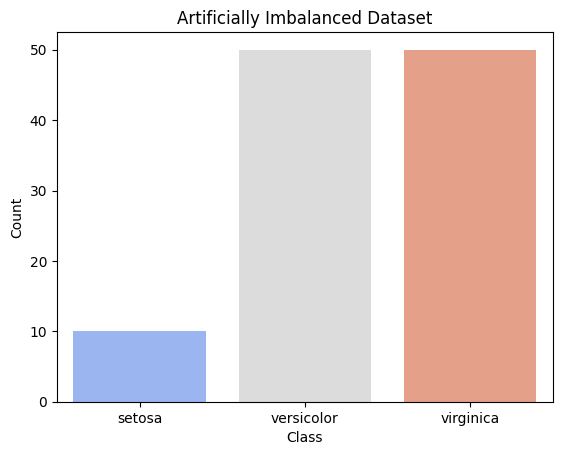

In [ ]:
sns.countplot(x=df['species'], palette="coolwarm")
plt.title("Artificially Imbalanced Dataset")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [ ]:
X = df.drop('species', axis=1)
y = df['species']

In [ ]:
from collections import Counter
# Split imbalanced data
# ❌ Split WITHOUT stratify (bad practice, just for demonstration)
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train distribution:", Counter(y_train_i))
print("Test distribution:", Counter(y_test_i))


Train distribution: Counter({'versicolor': 41, 'virginica': 39, 'setosa': 8})
Test distribution: Counter({'virginica': 11, 'versicolor': 9, 'setosa': 2})


In [ ]:
# Split WITH stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train distribution:", Counter(y_train))
print("Test distribution:", Counter(y_test))

Train distribution: Counter({'versicolor': 40, 'virginica': 40, 'setosa': 8})
Test distribution: Counter({'virginica': 10, 'versicolor': 10, 'setosa': 2})


# **Oversampling**

Oversampling provides a method to rebalance classes before model training commences. **By replicating minority class** data points, oversampling balances the playing field and prevents algorithms from disregarding significant yet sparse classes.

Common oversampling techniques include random oversampling, **SMOTE (Synthetic Minority Oversampling Technique)**, and ADASYN (Adaptive Synthetic Sampling Approach for Imbalanced Learning). Random oversampling naively duplicates minority examples, while SMOTE and ADASYN strategically generate synthetic new data to augment real instances.

**Notes:**

* **SMOTE** is industry standard

* Use **ADASYN** when your dataset has a complex decision boundary and the classes are heavily overlapping.


**(a).** **Random Oversampling**

In [ ]:
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN

After Oversampling: Counter({'setosa': 50, 'versicolor': 50, 'virginica': 50})


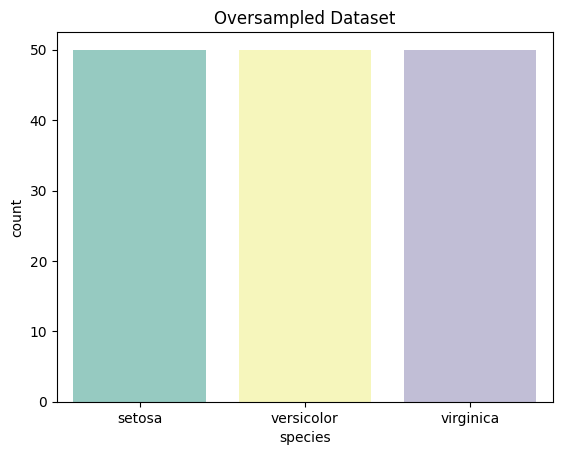

In [ ]:
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X, y)
print("After Oversampling:", Counter(y_ros))

sns.countplot(x=y_ros, palette="Set3")
plt.title("Oversampled Dataset")
plt.show()

In [ ]:
X_ros.duplicated().sum()
# Overfitting might occur

np.int64(41)

**SMOTE (Synthetic Minority Oversampling Technique)**

After SMOTE: Counter({'setosa': 50, 'versicolor': 50, 'virginica': 50})


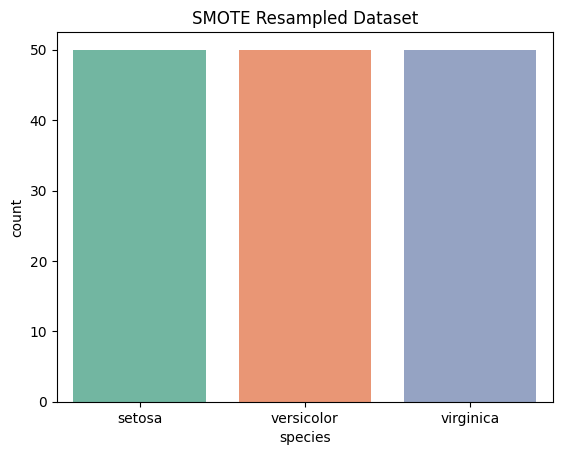

In [ ]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)
print("After SMOTE:", Counter(y_smote))

sns.countplot(x=y_smote, palette="Set2")
plt.title("SMOTE Resampled Dataset")
plt.show()

In [ ]:
X_smote.duplicated().sum()

np.int64(1)

**ADASYN (Adaptive Synthetic Sampling)**

### **How ADASYN Works**

ADASYN dynamically shifts the classification decision boundary toward the difficult examples. It does this by looking at the neighborhood of each minority sample. If a minority sample is surrounded by a lot of majority class samples, the algorithm considers it a "hard" example and generates more synthetic samples around it.


### **SMOTE vs. ADASYN: When to use which?**

* **Use SMOTE** as your baseline for synthetic oversampling. It is computationally slightly faster and works incredibly well for most standard imbalanced datasets.
* **Use ADASYN** when your dataset has a complex decision boundary and the classes are heavily overlapping. By forcing the model to focus on the minority samples trapped deep inside the majority class's territory, ADASYN can sometimes yield better precision and recall for the minority class.

Would you like to look at undersampling techniques next, or would you prefer to see how to combine oversampling with undersampling (like SMOTEENN or SMOTETomek)?

In [ ]:
# # Initialize ADASYN
# adasyn = ADASYN(random_state=42)

# # Fit and resample the dataset
# X_adasyn, y_adasyn = adasyn.fit_resample(X, y)

# # Check the class distribution
# print("After ADASYN:", Counter(y_adasyn))

# # Visualize the resampled dataset
# sns.countplot(x=y_adasyn, palette="Set1")
# plt.title("ADASYN Resampled Dataset")
# plt.show()

RuntimeError: Not any neigbours belong to the majority class. This case will induce a NaN case with a division by zero. ADASYN is not suited for this specific dataset. Use SMOTE instead.

Ah, you have hit a very interesting mathematical edge case! This is actually a great learning moment because the error message gives us a massive clue about the physical "shape" of your dataset.

### Why did this happen?

Remember how we discussed that ADASYN looks for "hard" examples by looking at the $K$ nearest neighbors (which defaults to 5) of each minority sample and counting how many belong to the *majority* class?

This `RuntimeError` happens when your minority class is in a tight, isolated cluster completely separated from the majority class.

For **every single** minority sample in your dataset, its 5 nearest neighbors are *also* minority samples. Because it found **0** majority neighbors across the board, the total sum of the density ratios is **0**. When ADASYN tries to normalize the distribution (by dividing by that sum), it triggers a divide-by-zero error.

In short: **Your dataset is too "easy" for ADASYN.** There are no overlapping, hard-to-learn examples at the boundary.

### How to fix it

You have two main paths forward here:

**1. Follow the error's advice (Stick to SMOTE)**
As the traceback explicitly states: `"ADASYN is not suited for this specific dataset. Use SMOTE instead."` Because SMOTE only cares about connecting minority samples to other minority samples and ignores the majority class entirely, it won't crash when the classes are perfectly separated.

**2. Expand the Neighborhood (Force ADASYN to work)**
If you really want to see ADASYN in action, you can force it to cast a wider net by increasing the `n_neighbors` parameter. By making it look at the 10, 20, or 50 nearest neighbors, it will eventually reach far enough across the "empty space" to find a majority sample.

You can modify your code like this:

```python
# Increase n_neighbors (default is 5).
# You may need to play with this number depending on how separated your data is.
adasyn = ADASYN(n_neighbors=15, random_state=42)

try:
    X_adasyn, y_adasyn = adasyn.fit_resample(X, y)
    print("After ADASYN:", Counter(y_adasyn))
    
    sns.countplot(x=y_adasyn, palette="Set1")
    plt.title("ADASYN Resampled Dataset")
    plt.show()
except RuntimeError as e:
    print(f"Still failing: {e}")
    print("Try increasing n_neighbors further, or stick to SMOTE.")
```

# **Undersampling**

Undersampling is a data preprocessing technique used in machine learning to balance imbalanced datasets by **reducing the number of samples in the majority class**. It helps prevent models from becoming biased toward the majority class, although it risks losing valuable information needed for accurate classification.

**1. Random Under-Sampling**

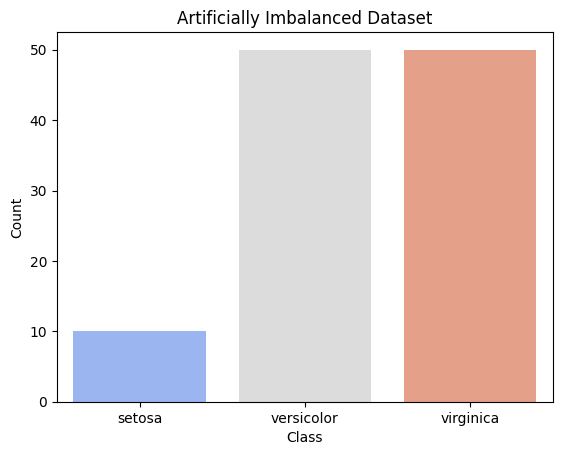

In [ ]:
sns.countplot(x=df['species'], palette="coolwarm")
plt.title("Artificially Imbalanced Dataset")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [ ]:
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, NearMiss

In [ ]:
X.value_counts().sum()

np.int64(110)

In [ ]:
y.value_counts().sum()

np.int64(110)

In [ ]:
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X, y)
print("After Undersampling:", Counter(y_rus))

After Undersampling: Counter({'setosa': 10, 'versicolor': 10, 'virginica': 10})


In [ ]:
X_rus.value_counts().sum()

np.int64(30)

In [ ]:
y_rus.value_counts().sum()

np.int64(30)

# **🔗 References:**

* https://www.mastersindatascience.org/learning/statistics-data-science/undersampling/

* https://www.geeksforgeeks.org/machine-learning/handling-imbalanced-data-for-classification/

* https://github.com/lovnishverma/Python-Getting-Started/blob/main/Distribute_Datasets_for_Classification_Models.ipynb

* https://machinelearningmastery.com/undersampling-algorithms-for-imbalanced-classification/

